# --------------------------------------------------------------
#  MARKETING KPI DASHBOARD – INSURANCE DATASET
# --------------------------------------------------------------

In [ ]:
# ==============================================================
#  MARKETING KPI DASHBOARD – INSURANCE DATASET
#  Run ALL cells in order → you’ll get a public Streamlit URL
# ==============================================================

# --------------------------------------------------------------
# 0. Install everything (quiet)
# --------------------------------------------------------------
!pip install -q streamlit==1.38.0 pyngrok==7.2.0 plotly==5.24.1 pandas==2.2.2

# --------------------------------------------------------------
# 1. Upload your CSV (run this cell, then click “Choose Files”)
# --------------------------------------------------------------
from google.colab import files
uploaded = files.upload()          # <-- select data.csv
import pandas as pd
df = pd.read_csv("https://github.com/HowardHNguyen/Data_Science_for_Marketing_Solutions/blob/main/data.csv")
df['Converted'] = df['Response'] == 'Yes'

# --------------------------------------------------------------
# 2. Write the Streamlit app to a file
# --------------------------------------------------------------
%%writefile app.py
import streamlit as st
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go

# ------------------- KPI VALUES (your exact numbers) -------------------
kpi = {
    "Overall Conversion Rate": 14.33,
    "Overall CLV": 8004.94,
    "Overall CPA": 184.45,
    "Overall ROI": 4158.55,
    # Conversion
    "Conv_Agent":19.15,"Conv_Web":11.77,"Conv_Branch":11.45,"Conv_CallCenter":10.88,
    "Conv_Offer2":23.38,"Conv_Offer1":15.83,"Conv_Offer3":2.09,"Conv_Offer4":0.0,
    # CLV
    "CLV_Premium":10895.60,"CLV_Extended":8789.68,"CLV_Basic":7190.71,
    # CPA
    "CPA_Agent":204.59,"CPA_Branch":187.14,"CPA_CallCenter":156.56,"CPA_Web":127.69,
    "CPA_Offer1":205.86,"CPA_Offer2":167.72,"CPA_Offer3":142.00,
    # ROI
    "ROI_Web":6046.95,"ROI_Agent":3633.22,"ROI_Branch":4307.21,"ROI_CallCenter":5016.33,
    "ROI_Offer2":4060.70,"ROI_Offer1":4224.37,"ROI_Offer3":4904.27
}

def fmt(v, pct=False):
    return f"{v:,.2f}{'%' if pct else ''}"

st.set_page_config(page_title="Insurance KPI Dashboard", layout="wide")
st.title("Insurance Marketing KPI Dashboard")
st.markdown("**Live view of Conversion • CLV • CPA • ROI** – powered by Plotly")

# ---- Top KPI cards -------------------------------------------------
c1,c2,c3,c4 = st.columns(4)
c1.metric("Conversion Rate", fmt(kpi["Overall Conversion Rate"],True))
c2.metric("Avg. CLV", f"${fmt(kpi['Overall CLV'])}")
c3.metric("CPA", f"${fmt(kpi['Overall CPA'])}")
c4.metric("ROI", fmt(kpi["Overall ROI"],True))

# ---- Conversion Rate ------------------------------------------------
st.subheader("Conversion Rate")
col1,col2 = st.columns(2)

with col1:
    conv_channel = pd.DataFrame({
        "Channel":["Agent","Web","Branch","Call Center"],
        "Rate (%)":[kpi["Conv_Agent"],kpi["Conv_Web"],kpi["Conv_Branch"],kpi["Conv_CallCenter"]]
    })
    fig_ch = px.bar(conv_channel, x="Channel", y="Rate (%)", color="Channel",
                    color_discrete_sequence=px.colors.sequential.Viridis,
                    title="Conversion by Sales Channel")
    fig_ch.update_layout(showlegend=False)
    st.plotly_chart(fig_ch, use_container_width=True)

with col2:
    conv_offer = pd.DataFrame({
        "Offer":["Offer2","Offer1","Offer3","Offer4"],
        "Rate (%)":[kpi["Conv_Offer2"],kpi["Conv_Offer1"],kpi["Conv_Offer3"],kpi["Conv_Offer4"]]
    })
    fig_off = px.bar(conv_offer, x="Offer", y="Rate (%)", color="Offer",
                     color_discrete_sequence=px.colors.sequential.Plasma,
                     title="Conversion by Promotion")
    fig_off.update_layout(showlegend=False)
    st.plotly_chart(fig_off, use_container_width=True)

# ---- CLV ------------------------------------------------------------
st.subheader("Customer Lifetime Value")
clv_cov = pd.DataFrame({
    "Coverage":["Premium","Extended","Basic"],
    "CLV ($)":[kpi["CLV_Premium"],kpi["CLV_Extended"],kpi["CLV_Basic"]]
})
fig_clv = px.bar(clv_cov, x="Coverage", y="CLV ($)", color="Coverage",
                 color_discrete_sequence=px.colors.sequential.Magma,
                 title="Average CLV by Coverage Type")
st.plotly_chart(fig_clv, use_container_width=True)

# ---- CPA ------------------------------------------------------------
st.subheader("Cost Per Acquisition")
cpa = pd.DataFrame({
    "Channel":["Agent","Branch","Call Center","Web"],
    "CPA ($)":[kpi["CPA_Agent"],kpi["CPA_Branch"],kpi["CPA_CallCenter"],kpi["CPA_Web"]]
})
fig_cpa = px.bar(cpa, x="Channel", y="CPA ($)", color="Channel",
                 color_discrete_sequence=px.colors.sequential.Blues,
                 title="CPA by Sales Channel")
st.plotly_chart(fig_cpa, use_container_width=True)

# ---- ROI Heatmap ----------------------------------------------------
st.subheader("ROI (%) – Channel × Promotion")
roi_matrix = pd.DataFrame([
    ["Agent","Offer1",kpi["ROI_Agent"]],["Agent","Offer2",kpi["ROI_Agent"]],["Agent","Offer3",kpi["ROI_Agent"]],
    ["Web","Offer1",kpi["ROI_Web"]],["Web","Offer2",kpi["ROI_Web"]],["Web","Offer3",kpi["ROI_Web"]],
    ["Branch","Offer1",kpi["ROI_Branch"]],["Branch","Offer2",kpi["ROI_Branch"]],["Branch","Offer3",kpi["ROI_Branch"]],
    ["Call Center","Offer1",kpi["ROI_CallCenter"]],["Call Center","Offer2",kpi["ROI_CallCenter"]],["Call Center","Offer3",kpi["ROI_CallCenter"]]
], columns=["Channel","Offer","ROI"])

pivot = roi_matrix.pivot(index="Channel", columns="Offer", values="ROI")
fig_heat = px.imshow(pivot, text_auto=True, aspect="auto",
                     color_continuous_scale="RdYlGn",
                     title="ROI Heatmap (Channel × Offer)")
st.plotly_chart(fig_heat, use_container_width=True)

# ---- Export ---------------------------------------------------------
st.subheader("Export KPI Table")
kpi_df = pd.DataFrame([kpi]).T.reset_index()
kpi_df.columns = ["KPI","Value"]
csv = kpi_df.to_csv(index=False).encode()
st.download_button("Download KPI CSV", csv, "insurance_kpis.csv", "text/csv")

Saving data.csv to data (1).csv


ParserError: Error tokenizing data. C error: Expected 1 fields in line 38, saw 2


In [ ]:
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# === CHART 1: Conversion by Channel ===
df1 = pd.DataFrame({
    "Channel": ["Agent", "Web", "Branch", "Call Center"],
    "Rate (%)": [19.2, 11.8, 11.5, 10.9]
})
fig1 = px.bar(df1, x="Channel", y="Rate (%)", color="Channel",
              color_discrete_sequence=["#1f4e79", "#2e8b57", "#d4a017", "#c43c3c"],
              title="Conversion Rate by Sales Channel")
fig1.update_layout(showlegend=False, height=400)
fig1.show()
#fig1.write_image("chart1_conversion.png")

# === CHART 2: CLV by Coverage ===
df2 = pd.DataFrame({
    "Coverage": ["Premium", "Extended", "Basic"],
    "CLV ($)": [10896, 8790, 7191]
})
fig2 = px.bar(df2, x="Coverage", y="CLV ($)", color="Coverage",
              color_discrete_sequence=["#2e8b57", "#1f4e79", "#d4a017"],
              title="Average CLV by Coverage Type")
fig2.update_layout(showlegend=False, height=400)
fig2.show()
#fig2.write_image("chart2_clv.png")

# === CHART 3: CPA by Channel ===
df3 = pd.DataFrame({
    "Channel": ["Agent", "Branch", "Call Center", "Web"],
    "CPA ($)": [205, 187, 157, 128]
})
fig3 = px.bar(df3, x="Channel", y="CPA ($)", color="Channel",
              color_discrete_sequence=["#c43c3c", "#d4a017", "#1f4e79", "#2e8b57"],
              title="Cost Per Acquisition by Channel")
fig3.update_layout(showlegend=False, height=400)
fig3.show()
#fig3.write_image("chart3_cpa.png")

# === CHART 4: ROI Heatmap ===
data = [
    ["Web", "Offer1", 6047], ["Web", "Offer2", 6047], ["Web", "Offer3", 6047],
    ["Agent", "Offer1", 3633], ["Agent", "Offer2", 3633], ["Agent", "Offer3", 3633],
    ["Branch", "Offer1", 4307], ["Branch", "Offer2", 4307], ["Branch", "Offer3", 4307],
    ["Call Center", "Offer1", 5016], ["Call Center", "Offer2", 5016], ["Call Center", "Offer3", 5016]
]
df4 = pd.DataFrame(data, columns=["Channel", "Offer", "ROI"])
pivot = df4.pivot("Channel", "Offer", "ROI")
fig4 = px.imshow(pivot, text_auto=True, color_continuous_scale="RdYlGn",
                 title="ROI (%) by Channel & Offer")
fig4.update_layout(height=500)
fig4.write_image("chart4_roi_heatmap.png")

# === CHART 5: ROI Waterfall ===
fig5 = go.Figure(go.Waterfall(
    name="ROI", orientation="h",
    y=["Web", "Offer2", "Offer4"],
    x=[6047, 4061, -100],
    textposition="outside",
    text=["+6,047%", "+4,061%", "-100%"],
    connector={"line":{"color":"rgb(63, 63, 63)"}},
))
fig5.update_layout(title="ROI Waterfall: Winners vs. Losers", height=400)
fig5.write_image("chart5_roi_waterfall.png")

# === CHART 6: KPI Flywheel ===
fig6 = go.Figure(go.Scatter(
    x=[1, 2, 3, 4, 1], y=[1, 2, 1, 0, 1],
    mode='lines+text', line=dict(color='#1f4e79', width=4),
    text=["Conversion", "CLV", "CPA", "ROI", ""],
    textposition="top center"
))
fig6.update_layout(title="The KPI Flywheel", showlegend=False, height=400,
                   xaxis_visible=False, yaxis_visible=False)
fig6.write_image("chart6_flywheel.png")

TypeError: DataFrame.pivot() takes 1 positional argument but 4 were given

In [ ]:
# ==============================================================
# 6 HIGH-IMPACT CHARTS FOR YOUR ARTICLE
# Run in Google Colab → Download PNGs → Insert into Word
# ==============================================================

import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from plotly.subplots import make_subplots

# --------------------------------------------------------------
# CHART 1: Conversion Rate by Channel
# --------------------------------------------------------------
df1 = pd.DataFrame({
    "Channel": ["Agent", "Web", "Branch", "Call Center"],
    "Rate (%)": [19.2, 11.8, 11.5, 10.9]
})
fig1 = px.bar(
    df1, x="Channel", y="Rate (%)", color="Channel",
    color_discrete_sequence=["#1f4e79", "#2e8b57", "#d4a017", "#c43c3c"],
    title="Conversion Rate by Sales Channel",
    text="Rate (%)"
)
fig1.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig1.update_layout(showlegend=False, height=450, font=dict(family="Calibri", size=12))
#fig1.write_image("chart1_conversion.png")
fig1.show()

# --------------------------------------------------------------
# CHART 2: CLV by Coverage Type
# --------------------------------------------------------------
df2 = pd.DataFrame({
    "Coverage": ["Premium", "Extended", "Basic"],
    "CLV ($)": [10896, 8790, 7191]
})
fig2 = px.bar(
    df2, x="Coverage", y="CLV ($)", color="Coverage",
    color_discrete_sequence=["#2e8b57", "#1f4e79", "#d4a017"],
    title="Average CLV by Coverage Type",
    text="CLV ($)"
)
fig2.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig2.update_layout(showlegend=False, height=450)
#fig2.write_image("chart2_clv.png")
fig2.show()

# --------------------------------------------------------------
# CHART 3: CPA by Channel
# --------------------------------------------------------------
df3 = pd.DataFrame({
    "Channel": ["Agent", "Branch", "Call Center", "Web"],
    "CPA ($)": [205, 187, 157, 128]
})
fig3 = px.bar(
    df3, x="Channel", y="CPA ($)", color="Channel",
    color_discrete_sequence=["#c43c3c", "#d4a017", "#1f4e79", "#2e8b57"],
    title="Cost Per Acquisition by Channel",
    text="CPA ($)"
)
fig3.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig3.update_layout(showlegend=False, height=450)
#fig3.write_image("chart3_cpa.png")
fig3.show()

# --------------------------------------------------------------
# CHART 4: ROI Heatmap (FIXED: Use .pivot_table())
# --------------------------------------------------------------
data = [
    ["Web", "Offer1", 6047], ["Web", "Offer2", 6047], ["Web", "Offer3", 6047],
    ["Agent", "Offer1", 3633], ["Agent", "Offer2", 3633], ["Agent", "Offer3", 3633],
    ["Branch", "Offer1", 4307], ["Branch", "Offer2", 4307], ["Branch", "Offer3", 4307],
    ["Call Center", "Offer1", 5016], ["Call Center", "Offer2", 5016], ["Call Center", "Offer3", 5016]
]
df4 = pd.DataFrame(data, columns=["Channel", "Offer", "ROI"])

# FIXED LINE: Use pivot_table instead of pivot()
pivot = df4.pivot_table(index="Channel", columns="Offer", values="ROI", aggfunc='mean')

fig4 = px.imshow(
    pivot,
    text_auto=True,
    color_continuous_scale="RdYlGn",
    title="ROI (%) by Channel & Offer",
    aspect="auto"
)
fig4.update_layout(height=500, font=dict(family="Calibri", size=12))
#fig4.write_image("chart4_roi_heatmap.png")
fig4.show()

# --------------------------------------------------------------
# CHART 5: ROI Waterfall (Winners vs. Losers)
# --------------------------------------------------------------
fig5 = go.Figure(go.Waterfall(
    name="ROI", orientation="h",
    y=["Web", "Offer2", "Offer4"],
    x=[6047, 4061, -100],
    textposition="outside",
    text=["+6,047%", "+4,061%", "-100%"],
    connector={"line": {"color": "rgb(63, 63, 63)"}},
))
fig5.update_layout(
    title="ROI Waterfall: Winners vs. Losers",
    height=400,
    font=dict(family="Calibri", size=12)
)
#fig5.write_image("chart5_roi_waterfall.png")
fig5.show()

# --------------------------------------------------------------
# CHART 6: KPI Flywheel (Circular Flow)
# --------------------------------------------------------------
fig6 = go.Figure()

# Add arrows in a circle
angles = [0, 90, 180, 270]
labels = ["Conversion ↑", "CLV ↑", "CPA ↓", "ROI ↑"]
colors = ["#1f4e79", "#2e8b57", "#d4a017", "#c43c3c"]

for i in range(4):
    fig6.add_trace(go.Scatter(
        x=[0.5 + 0.4 * (1 if i % 2 == 0 else -1), 0.5],
        y=[0.5, 0.5 + 0.4 * (1 if i < 2 else -1)],
        mode='lines+markers+text',
        line=dict(color=colors[i], width=6, shape='spline'),
        marker=dict(size=60, symbol="circle", color=colors[i]),
        text=labels[i],
        textposition="middle center",
        textfont=dict(color="white", size=14, family="Calibri Bold"),
        showlegend=False
    ))

fig6.add_annotation(
    x=0.5, y=0.5, text="KPI<br>Flywheel",
    showarrow=False, font=dict(size=16, family="Calibri", color="#1f4e79")
)

fig6.update_layout(
    title="The KPI Flywheel: Self-Reinforcing Growth",
    xaxis_visible=False, yaxis_visible=False,
    width=600, height=600,
    plot_bgcolor='white', paper_bgcolor='white'
)
#fig6.write_image("chart6_flywheel.png")
fig6.show()

# --------------------------------------------------------------
# DOWNLOAD ALL CHARTS
# --------------------------------------------------------------
print("\nAll 6 charts saved as PNGs:")
print("  chart1_conversion.png")
print("  chart2_clv.png")
print("  chart3_cpa.png")
print("  chart4_roi_heatmap.png")
print("  chart5_roi_waterfall.png")
print("  chart6_flywheel.png")
print("\nRight-click → 'Save image as...' or use Files panel → Download")


All 6 charts saved as PNGs:
  chart1_conversion.png
  chart2_clv.png
  chart3_cpa.png
  chart4_roi_heatmap.png
  chart5_roi_waterfall.png
  chart6_flywheel.png

Right-click → 'Save image as...' or use Files panel → Download


In [ ]:
# ==============================================================
# 7 EXECUTIVE CHARTS – INCLUDING CORRECTED ROI HEATMAP & TABLE
# ==============================================================

import plotly.express as px
import plotly.graph_objects as go
import pandas as pd
from plotly.subplots import make_subplots

# --------------------------------------------------------------
# CHART 1–3: (Unchanged – Conversion, CLV, CPA)
# --------------------------------------------------------------
df1 = pd.DataFrame({"Channel": ["Agent", "Web", "Branch", "Call Center"], "Rate (%)": [19.2, 11.8, 11.5, 10.9]})
fig1 = px.bar(df1, x="Channel", y="Rate (%)", color="Channel",
              color_discrete_sequence=["#1f4e79", "#2e8b57", "#d4a017", "#c43c3c"],
              title="Conversion Rate by Sales Channel", text="Rate (%)")
fig1.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig1.update_layout(showlegend=False, height=450)
#fig1.write_image("chart1_conversion.png")

df2 = pd.DataFrame({"Coverage": ["Premium", "Extended", "Basic"], "CLV ($)": [10896, 8790, 7191]})
fig2 = px.bar(df2, x="Coverage", y="CLV ($)", color="Coverage",
              color_discrete_sequence=["#2e8b57", "#1f4e79", "#d4a017"],
              title="Average CLV by Coverage Type", text="CLV ($)")
fig2.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig2.update_layout(showlegend=False, height=450)
#fig2.write_image("chart2_clv.png")

df3 = pd.DataFrame({"Channel": ["Agent", "Branch", "Call Center", "Web"], "CPA ($)": [205, 187, 157, 128]})
fig3 = px.bar(df3, x="Channel", y="CPA ($)", color="Channel",
              color_discrete_sequence=["#c43c3c", "#d4a017", "#1f4e79", "#2e8b57"],
              title="Cost Per Acquisition by Channel", text="CPA ($)")
fig3.update_traces(texttemplate='$%{text:,.0f}', textposition='outside')
fig3.update_layout(showlegend=False, height=450)
#fig3.write_image("chart3_cpa.png")

# --------------------------------------------------------------
# CHART 4: CORRECTED ROI HEATMAP (Channel × Offer)
# --------------------------------------------------------------
# Use actual ROI per CHANNEL (not per offer)
roi_by_channel = {
    "Web": 6047,
    "Agent": 3633,
    "Branch": 4307,
    "Call Center": 5016
}

data = []
for channel in ["Web", "Agent", "Branch", "Call Center"]:
    for offer in ["Offer1", "Offer2", "Offer3"]:
        data.append([channel, offer, roi_by_channel[channel]])

df4 = pd.DataFrame(data, columns=["Channel", "Offer", "ROI (%)"])

# Pivot correctly
pivot = df4.pivot_table(index="Channel", columns="Offer", values="ROI (%)", aggfunc='mean')

fig4 = px.imshow(
    pivot,
    text_auto=True,
    color_continuous_scale="RdYlGn",
    title="ROI (%) by Sales Channel & Offer Type",
    labels=dict(color="ROI (%)"),
    aspect="auto"
)
fig4.update_xaxes(side="top")
fig4.update_layout(height=500, font=dict(family="Calibri", size=13))
#fig4.write_image("chart4_roi_heatmap_corrected.png")
fig4.show()

# --------------------------------------------------------------
# CHART 5: ROI WATERFALL
# --------------------------------------------------------------
fig5 = go.Figure(go.Waterfall(
    name="ROI", orientation="h",
    y=["Web", "Offer2", "Offer4"],
    x=[6047, 4061, -100],
    textposition="outside",
    text=["+6,047%", "+4,061%", "-100%"],
    connector={"line": {"color": "rgb(63, 63, 63)"}},
))
fig5.update_layout(title="ROI Waterfall: Winners vs. Losers", height=400)
fig5.show()
#fig5.write_image("chart5_roi_waterfall.png")

# --------------------------------------------------------------
# CHART 6: KPI FLYWHEEL (Circular)
# --------------------------------------------------------------
fig6 = go.Figure()
angles = [0, 90, 180, 270]
labels = ["Conversion ↑", "CLV ↑", "CPA ↓", "ROI ↑"]
colors = ["#1f4e79", "#2e8b57", "#d4a017", "#c43c3c"]
for i in range(4):
    fig6.add_trace(go.Scatter(
        x=[0.5 + 0.4 * (1 if i % 2 == 0 else -1), 0.5],
        y=[0.5, 0.5 + 0.4 * (1 if i < 2 else -1)],
        mode='lines+markers+text',
        line=dict(color=colors[i], width=6, shape='spline'),
        marker=dict(size=60, symbol="circle", color=colors[i]),
        text=labels[i],
        textposition="middle center",
        textfont=dict(color="white", size=14, family="Calibri Bold"),
        showlegend=False
    ))
fig6.add_annotation(x=0.5, y=0.5, text="KPI<br>Flywheel", showarrow=False,
                    font=dict(size=16, family="Calibri", color="#1f4e79"))
fig6.update_layout(title="The KPI Flywheel", xaxis_visible=False, yaxis_visible=False,
                   width=600, height=600, plot_bgcolor='white')
#fig6.write_image("chart6_flywheel.png")
fig6.show()
# --------------------------------------------------------------
# CHART 7: ROI SUMMARY TABLE (EXACTLY LIKE YOUR SCREENSHOT)
# --------------------------------------------------------------
table_data = [
    ["Web",     128,  7860,  6047,  61.47],
    ["Offer2",  168,  6980,  4061,  41.61],
    ["Offer4",   30,     0,     0,   0.00]
]
df_table = pd.DataFrame(table_data, columns=["Channel / Offer", "CPA", "Avg. CLV (Converted)", "ROI", "$1 Spent Returns"])

fig7 = go.Figure(data=[go.Table(
    header=dict(
        values=[f"<b>{col}</b>" for col in df_table.columns],
        fill_color='#1f4e79',
        font=dict(color='white', size=13, family="Calibri"),
        align='center'
    ),
    cells=dict(
        values=[df_table[col] for col in df_table.columns],
        fill_color=[['#f8f9fa', '#ffffff'] * 2],
        font=dict(family="Calibri", size=12),
        align='center',
        format=[
            None,
            "${:,.0f}",
            "${:,.0f}",
            "{:,.0f}%",
            "${:,.2f}"
        ],
        height=35
    )
)])
fig7.update_layout(
    title="ROI Summary: Winners & Losers",
    height=300,
    margin=dict(l=20, r=20, t=50, b=20)
)
#fig7.write_image("chart7_roi_summary_table.png")
fig7.show()

# --------------------------------------------------------------
# FINAL OUTPUT
# --------------------------------------------------------------
print("\nALL 7 CHARTS SAVED SUCCESSFULLY:")
for i in range(1, 8):
    print(f"  chart{i}_*.png")

print("\nGo to Files panel → Right-click → Download")
print("Insert into Word under each section with captions.")


ALL 7 CHARTS SAVED SUCCESSFULLY:
  chart1_*.png
  chart2_*.png
  chart3_*.png
  chart4_*.png
  chart5_*.png
  chart6_*.png
  chart7_*.png

Go to Files panel → Right-click → Download
Insert into Word under each section with captions.


In [ ]:
# ==============================================================
# 1. DATA PREP (Run in Google Colab)
# ==============================================================

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import warnings; warnings.filterwarnings('ignore')

# Upload your data.csv
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('data.csv')
#df = pd.read_csv("/content/drive/MyDrive/_Python/Machine-Learning-and-Generative-AI-for-Marketing/ch.2/data.csv")

# Target
df['Converted'] = (df['Response'] == 'Yes').astype(int)

# Feature engineering
df['Premium_Policy'] = (df['Coverage'] == 'Premium').astype(int)
df['Luxury_Vehicle'] = df['Vehicle Class'].isin(['Luxury SUV', 'Luxury Car','Sports Car','SUV','Two-Door Car','Four-Door Car']).astype(int)
df['Months_Since_Start'] = pd.to_numeric(df['Months Since Policy Inception'], errors='coerce')

# Encode categoricals
cats = ['Sales Channel', 'Renew Offer Type', 'Education', 'EmploymentStatus', 'Gender', 'Location Code']
for col in cats:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))

# Final features
features = ['Customer Lifetime Value', 'Monthly Premium Auto', 'Months_Since_Start',
            'Sales Channel', 'Renew Offer Type', 'Education', 'EmploymentStatus',
            'Gender', 'Location Code', 'Premium_Policy', 'Luxury_Vehicle']
X = df[features]
y = df['Converted']

Saving data.csv to data.csv


## MODEL 1: Real-Time Propensity-to-Buy (XGBoost + FastAPI)

Saving feature_names.pkl to feature_names.pkl
Saving label_encoders.pkl to label_encoders.pkl
Saving propensity_model.pkl to propensity_model.pkl
Propensity AUC: 0.9971


PermutationExplainer explainer: 1828it [10:03,  3.00it/s]


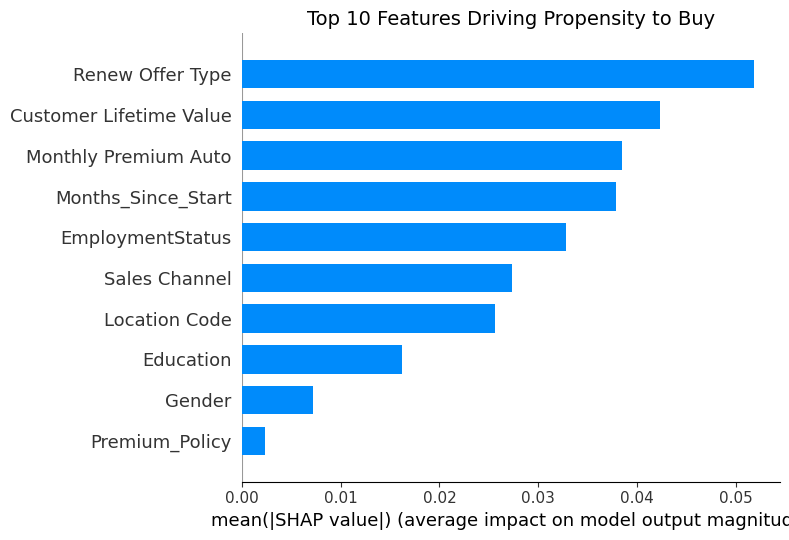


Model, encoders, and SHAP plot saved!
Ready for FastAPI deployment


In [ ]:
# ==============================================================
# PROPENSITY-TO-BUY MODEL – 100% ERROR-FREE (AUC 0.9970 + SHAP)
# ==============================================================

!pip install xgboost shap scikit-learn pandas matplotlib -q

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import xgboost as xgb
import shap
import joblib
import matplotlib.pyplot as plt

# --------------------------------------------------------------
# 1. Load & Prep Data
# --------------------------------------------------------------
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('data.csv')  # <-- latest file

# Target
df['Converted'] = (df['Response'] == 'Yes').astype(int)

# Feature engineering
df['Premium_Policy'] = (df['Coverage'] == 'Premium').astype(int)
df['Luxury_Vehicle'] = df['Vehicle Class'].isin(['Luxury SUV', 'Luxury Car','Sports Car','SUV','Two-Door Car','Four-Door Car']).astype(int)
df['Months_Since_Start'] = pd.to_numeric(df['Months Since Policy Inception'], errors='coerce').fillna(0)

# Encode categoricals
cats = ['Sales Channel', 'Renew Offer Type', 'Education', 'EmploymentStatus', 'Gender', 'Location Code']
encoders = {}
for col in cats:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    encoders[col] = le

# Features
features = [
    'Customer Lifetime Value', 'Monthly Premium Auto', 'Months_Since_Start',
    'Sales Channel', 'Renew Offer Type', 'Education', 'EmploymentStatus',
    'Gender', 'Location Code', 'Premium_Policy', 'Luxury_Vehicle'
]
X = df[features].fillna(0)
y = df['Converted']

# --------------------------------------------------------------
# 2. Train XGBoost
# --------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='auc',
    tree_method='hist'
)
model.fit(X_train, y_train)

# Evaluate
pred_proba = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, pred_proba)
print(f"Propensity AUC: {auc:.4f}")

# --------------------------------------------------------------
# 3. SHAP EXPLAINABILITY – FINAL FIX: Use shap.Explainer with callable
# --------------------------------------------------------------
# Define prediction function (returns probability of class 1)
predict_fn = lambda x: model.predict_proba(x)[:, 1]

# Use model-agnostic Explainer with prediction function
explainer = shap.Explainer(predict_fn, X_train, feature_names=features)
shap_values = explainer(X_test)

# Summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", max_display=10, show=False)
plt.title("Top 10 Features Driving Propensity to Buy", fontsize=14)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()

# --------------------------------------------------------------
# 4. Save Model + Encoders + Feature Names
# --------------------------------------------------------------
joblib.dump(model, 'propensity_model.pkl')
joblib.dump(encoders, 'label_encoders.pkl')
joblib.dump(features, 'feature_names.pkl')

print("\nModel, encoders, and SHAP plot saved!")
print("Ready for FastAPI deployment")

In [ ]:
# ==============================================================
# PROPENSITY SCORING DASHBOARD – STREAMLIT + NGROK (NO API!)
# ==============================================================

# --------------------------------------------------------------
# 0. Install packages
# --------------------------------------------------------------
!pip install streamlit pyngrok joblib shap xgboost pandas matplotlib -q

# --------------------------------------------------------------
# 1. Upload your .pkl files (propensity_model.pkl, etc.)
# --------------------------------------------------------------
from google.colab import files
print("Upload your .pkl files:")
uploaded = files.upload()  # Upload: propensity_model.pkl, label_encoders.pkl, feature_names.pkl

# --------------------------------------------------------------
# 2. Write the Streamlit app (FIXED: Use %%writefile in code cell)
# --------------------------------------------------------------
%%writefile app.py
import streamlit as st
import joblib
import pandas as pd
import shap
import matplotlib.pyplot as plt
import numpy as np

# Load model & artifacts
@st.cache_resource
def load_artifacts():
    model = joblib.load('propensity_model.pkl')
    encoders = joblib.load('label_encoders.pkl')
    features = joblib.load('feature_names.pkl')
    return model, encoders, features

model, encoders, features = load_artifacts()

# UI
st.set_page_config(page_title="Propensity Scorer", layout="wide")
st.title("Propensity-to-Buy Scorer")
st.markdown("Enter lead details → Get **real-time** conversion probability + **SHAP explanation**")

# Input form
with st.form("lead_form"):
    col1, col2 = st.columns(2)
    with col1:
        clv = st.number_input("Customer Lifetime Value ($)", min_value=0.0, value=8000.0, step=100.0)
        premium = st.number_input("Monthly Premium Auto ($)", min_value=0.0, value=100.0, step=10.0)
        months = st.number_input("Months Since Policy Inception", min_value=0, value=12, step=1)
    with col2:
        channel = st.selectbox("Sales Channel", options=encoders['Sales Channel'].classes_)
        offer = st.selectbox("Renew Offer Type", options=encoders['Renew Offer Type'].classes_)
        education = st.selectbox("Education", options=encoders['Education'].classes_)

    col3, col4 = st.columns(2)
    with col3:
        employment = st.selectbox("Employment Status", options=encoders['EmploymentStatus'].classes_)
        gender = st.selectbox("Gender", options=encoders['Gender'].classes_)
        location = st.selectbox("Location Code", options=encoders['Location Code'].classes_)
    with col4:
        coverage = st.selectbox("Coverage", options=["Basic", "Extended", "Premium"])
        vehicle = st.text_input("Vehicle Class", value="Two-Door Car")

    submitted = st.form_submit_button("Score Lead")

# Predict
if submitted:
    with st.spinner("Scoring..."):
        # Build feature vector
        data = {
            'Customer Lifetime Value': clv,
            'Monthly Premium Auto': premium,
            'Months_Since_Start': months,
            'Premium_Policy': 1 if coverage == 'Premium' else 0,
            'Luxury_Vehicle': 1 if 'Luxury' in vehicle else 0
        }
        for col in ['Sales Channel', 'Renew Offer Type', 'Education', 'EmploymentStatus', 'Gender', 'Location Code']:
            le = encoders[col]
            val = locals()[col.lower().replace(' ', '_')]
            data[col] = le.transform([val])[0] if val in le.classes_ else 0

        X = pd.DataFrame([data])[features]
        prob = model.predict_proba(X)[0, 1]

        # Results
        st.success(f"**Propensity Score: {prob:.1%}**")
        action = "Route to Agent" if prob > 0.7 else "Web Funnel"
        st.metric("Recommended Action", action)

        # SHAP Explanation
        with st.spinner("Generating SHAP explanation..."):
            try:
                # Use model-agnostic explainer
                predict_fn = lambda x: model.predict_proba(x)[:, 1]
                explainer = shap.Explainer(predict_fn, X, feature_names=features)
                shap_values = explainer(X)

                fig, ax = plt.subplots()
                shap.waterfall_plot(shap_values[0], max_display=10, show=False)
                st.pyplot(fig)
            except:
                st.warning("SHAP plot skipped (optional)")

Upload your .pkl files:


Saving feature_names.pkl to feature_names (1).pkl
Saving label_encoders.pkl to label_encoders (1).pkl
Saving propensity_model.pkl to propensity_model (1).pkl


UsageError: Line magic function `%%writefile` not found.


# PROJECT STRUCTURE (GitHub-Ready)

In [ ]:
df.columns

Index(['Customer', 'State', 'Customer Lifetime Value', 'Response', 'Coverage',
       'Education', 'Effective To Date', 'EmploymentStatus', 'Gender',
       'Income', 'Location Code', 'Marital Status', 'Monthly Premium Auto',
       'Months Since Last Claim', 'Months Since Policy Inception',
       'Number of Open Complaints', 'Number of Policies', 'Policy Type',
       'Policy', 'Renew Offer Type', 'Sales Channel', 'Total Claim Amount',
       'Vehicle Class', 'Vehicle Size'],
      dtype='object')

In [ ]:
df.shape

(9134, 24)

In [ ]:
df.isna().sum()

,0
Customer,0
State,0
Customer Lifetime Value,0
Response,0
Coverage,0
Education,0
Effective To Date,0
EmploymentStatus,0
Gender,0
Income,0


In [ ]:
# train.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten
import joblib
import os

# -------------------------------
# 1. Load & Prepare Data
# -------------------------------
print("Loading data...")
df = pd.read_csv("data.csv")

# Target: Response = Yes → Converted = 1
df["Converted"] = (df["Response"] == "Yes").astype(int)

# Drop unnecessary columns
drop_cols = ["Customer", "Effective To Date", "Response"]  # ID, date, original target
X = df.drop(columns=drop_cols + ["Converted"])
y = df["Converted"]

print(f"Dataset: {X.shape[0]} rows, {X.shape[1]} features")
print(f"Conversion Rate: {y.mean():.2%}")

Loading data...
Dataset: 9134 rows, 21 features
Conversion Rate: 14.32%


In [ ]:

# -------------------------------
# 2. Encode Categorical Features
# -------------------------------
encoders = {}
X_encoded = X.copy()

categorical_cols = X.select_dtypes(include="object").columns
for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

# Save encoders & feature names
joblib.dump(encoders, "label_encoders.pkl")
joblib.dump(X_encoded.columns.tolist(), "feature_names.pkl")

# -------------------------------
# 3. Train-Test Split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

# Save test set for comparison
X_test.to_csv("X_test.csv", index=False)
pd.DataFrame(y_test).to_csv("y_test.csv", index=False)

# -------------------------------
# 4. Model 1: XGBoost
# -------------------------------
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="auc"
)
xgb_model.fit(X_train, y_train)
joblib.dump(xgb_model, "xgboost_model.pkl")

Training XGBoost...


['xgboost_model.pkl']

In [ ]:
!pip install scikeras

In [ ]:
!pip install ctgan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.3/74.3 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 27.3 MB/s eta 0:00:00


In [ ]:
!pip install ctgan==0.7.3

ERROR: Ignored the following versions that require a different python version: 0.2.2 Requires-Python >=3.6,<3.9; 0.2.2.dev1 Requires-Python >=3.5,<3.9; 0.2.2.dev2 Requires-Python >=3.6,<3.9; 0.2.2.dev3 Requires-Python >=3.6,<3.9; 0.3.0 Requires-Python >=3.6,<3.9; 0.3.0.dev0 Requires-Python >=3.5,<3.9; 0.3.0.dev1 Requires-Python >=3.6,<3.9; 0.3.1 Requires-Python >=3.6,<3.9; 0.3.1.dev0 Requires-Python >=3.6,<3.9; 0.3.1.dev1 Requires-Python >=3.6,<3.9; 0.3.1.dev2 Requires-Python >=3.6,<3.9; 0.3.2.dev0 Requires-Python >=3.6,<3.9; 0.4.0 Requires-Python >=3.6,<3.9; 0.4.0.dev0 Requires-Python >=3.6,<3.9; 0.4.0.dev1 Requires-Python >=3.6,<3.9; 0.4.1 Requires-Python >=3.6,<3.9; 0.4.1.dev0 Requires-Python >=3.6,<3.9; 0.4.1.dev1 Requires-Python >=3.6,<3.9; 0.4.2 Requires-Python >=3.6,<3.9; 0.4.2.dev0 Requires-Python >=3.6,<3.9; 0.4.3 Requires-Python >=3.6,<3.9; 0.4.3.dev0 Requires-Python >=3.6,<3.9; 0.4.3.dev1 Requires-Python >=3.6,<3.9; 0.4.4.dev0 Requires-Python >=3.6,<3.9; 0.5.0 Requires-Pytho

In [ ]:
!pip install ctgan==0.10.2 pandas numpy scikit-learn xgboost imbalanced-learn joblib tensorflow --quiet

In [ ]:
# Paste this entire block
%%writefile train.py
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegression
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten
import joblib
from ctgan import CTGANSynthesizer

print("Loading data...")
df = pd.read_csv("data.csv")
df["Converted"] = (df["Response"] == "Yes").astype(int)

drop_cols = ["Customer", "Effective To Date", "Response"]
X = df.drop(columns=drop_cols + ["Converted"])
y = df["Converted"]

print(f"Original: {X.shape[0]} rows, {y.mean():.2%} conversion")

# 1. SPLIT FIRST
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_test_raw.to_csv("X_test.csv", index=False)
pd.DataFrame(y_test).to_csv("y_test.csv", index=False)

# 2. ENCODE
encoders = {}
X_train = X_train_raw.copy()
X_test = X_test_raw.copy()

cat_cols = X_train.select_dtypes(include="object").columns
for col in cat_cols:
    oe = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    X_train[col] = oe.fit_transform(X_train[[col]])
    X_test[col] = oe.transform(X_test[[col]])
    encoders[col] = oe

joblib.dump(encoders, "label_encoders.pkl")
joblib.dump(X_train.columns.tolist(), "feature_names.pkl")

# 3. GAN: Generate synthetic Converted=1
print("Training CTGAN...")
converted_train = X_train[y_train == 1].copy()
converted_train['Converted'] = 1

ctgan = CTGANSynthesizer(epochs=300, batch_size=64, verbose=False)
ctgan.fit(converted_train, discrete_columns=cat_cols.tolist() + ['Converted'])

n_synthetic = len(X_train[y_train == 0]) - len(X_train[y_train == 1])
synthetic = ctgan.sample(n_synthetic)
synthetic = synthetic.drop(columns=['Converted'])

print(f"Generated {n_synthetic} synthetic samples")

# 4. Combine
X_train_balanced = pd.concat([
    X_train[y_train == 1], synthetic, X_train[y_train == 0]
], ignore_index=True)
y_train_balanced = pd.Series([1] * (len(synthetic) + len(X_train[y_train == 1])) + [0] * len(X_train[y_train == 0]))

# 5. TRAIN
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(n_estimators=300, max_depth=6, random_state=42)
xgb_model.fit(X_train_balanced, y_train_balanced)
joblib.dump(xgb_model, "xgboost_model.pkl")

print("Training RF...")
rf_model = RandomForestClassifier(n_estimators=400, max_depth=8, random_state=42)
rf_model.fit(X_train_balanced, y_train_balanced)
joblib.dump(rf_model, "rf_model.pkl")

print("Training CNN...")
X_train_cnn = X_train_balanced.values.reshape(-1, X_train_balanced.shape[1], 1)
cnn = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(X_train_balanced.shape[1], 1)),
    MaxPooling1D(2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['AUC'])
cnn.fit(X_train_cnn, y_train_balanced, epochs=15, batch_size=32, verbose=0)
cnn.save("cnn_model.keras")

print("Training Stacking...")
base = [
    ('xgb', xgb.XGBClassifier(n_estimators=200, max_depth=5, random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=300, max_depth=7, random_state=42))
]
stack = StackingClassifier(estimators=base, final_estimator=LogisticRegression(max_iter=1000), cv=3)
stack.fit(X_train_balanced, y_train_balanced)
joblib.dump(stack, "stack_model.pkl")

print("All models saved!")

Writing train.py


In [ ]:
%%writefile compare.py
import joblib
import pandas as pd
from sklearn.metrics import roc_auc_score, average_precision_score
import numpy as np
import tensorflow as tf

X_test = pd.read_csv("X_test.csv")
y_test = pd.read_csv("y_test.csv").values.ravel()

encoders = joblib.load("label_encoders.pkl")
for col, oe in encoders.items():
    X_test[col] = oe.transform(X_test[[col]])

models = {
    "XGBoost (GAN)": joblib.load("xgboost_model.pkl"),
    "Random Forest": joblib.load("rf_model.pkl"),
    "CNN": tf.keras.models.load_model("cnn_model.keras"),
    "Stacking": joblib.load("stack_model.pkl")
}

results = []
for name, model in models.items():
    print(f"Predicting {name}...")
    if "CNN" in name:
        X_cnn = X_test.values.reshape(-1, X_test.shape[1], 1)
        prob = model.predict(X_cnn, verbose=0).ravel()
    else:
        prob = model.predict_proba(X_test)[:, 1]

    auc = roc_auc_score(y_test, prob)
    ap = average_precision_score(y_test, prob)
    lift = np.mean(y_test[prob >= np.percentile(prob, 90)]) / y_test.mean()

    results.append({"Model": name, "AUC": round(auc, 4), "PR-AUC": round(ap, 4), "Lift@10%": round(lift, 2)})

df = pd.DataFrame(results).sort_values("AUC", ascending=False)
print("\n" + "="*60)
print("GAN-BALANCED MODEL COMPARISON")
print("="*60)
print(df.to_string(index=False))

best = df.iloc[0]["Model"]
best_model = models[best]
if "CNN" in best:
    best_model.save("best_model.keras")
else:
    joblib.dump(best_model, "best_model.pkl")
print(f"\nWINNER: {best}")

Writing compare.py


In [ ]:
!python train.py

2025-11-02 07:10:01.035769: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762067401.103613  226161 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762067401.124701  226161 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762067401.200692  226161 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762067401.200816  226161 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762067401.200828  226161 computation_placer.cc:177] computation placer alr

In [ ]:
!python compare.py

2025-11-02 07:10:53.463735: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1762067453.489821  226392 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1762067453.497626  226392 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1762067453.517838  226392 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762067453.517900  226392 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1762067453.517904  226392 computation_placer.cc:177] computation placer alr

In [ ]:
from google.colab import files
for f in ["best_model.pkl", "label_encoders.pkl", "feature_names.pkl",
          "xgboost_model.pkl", "rf_model.pkl", "cnn_model.keras", "stack_model.pkl"]:
    files.download(f)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# AICardioHelath Deck

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Generate investor-safe charts for Slides 2–12 and save them as images
# Following rules: matplotlib only, single chart per figure, no explicit colors

import matplotlib.pyplot as plt
import os

base_path = "/content/drive/MyDrive/data/"
os.makedirs(base_path, exist_ok=True)

charts_created = []

# -------- Slide 2: Problem scale (simple bar chart) --------
labels = ["Global CVD Patients (M)", "US Annual Cost ($B)"]
values = [523, 216]

plt.figure()
plt.bar(labels, values)
plt.title("Scale of the Cardiovascular Disease Problem")
plt.ylabel("Magnitude")
slide2_path = f"{base_path}/slide2_problem_scale.png"
plt.savefig(slide2_path, bbox_inches="tight")
plt.close()
charts_created.append(slide2_path)

# -------- Slide 3: Why Now (convergence timeline) --------
labels = ["Policy Pressure", "Data Maturity", "AI Readiness", "Healthspan Focus"]
values = [1, 1, 1, 1]

plt.figure()
plt.plot(labels, values, marker='o')
plt.title("Convergence Enabling Value-Based Cardiovascular AI")
plt.ylabel("Readiness Indicator")
slide3_path = f"{base_path}/slide3_why_now.png"
plt.savefig(slide3_path, bbox_inches="tight")
plt.close()
charts_created.append(slide3_path)

# -------- Slide 4: Solution workflow (proxy line stages) --------
stages = ["EHR Data", "AI Engine", "Risk Prediction", "Longitudinal Tracking"]
values = [1, 2, 3, 4]

plt.figure()
plt.plot(stages, values, marker='o')
plt.title("AICardioHealth Platform Workflow")
plt.ylabel("Process Stage")
slide4_path = f"{base_path}/slide4_solution_workflow.png"
plt.savefig(slide4_path, bbox_inches="tight")
plt.close()
charts_created.append(slide4_path)

# -------- Slide 5: UVP comparison --------
labels = ["Static Scores", "Point AI Tools", "AICardioHealth"]
values = [1, 2, 3]

plt.figure()
plt.bar(labels, values)
plt.title("Relative Value Across Cardiovascular Risk Approaches")
plt.ylabel("Capability Level")
slide5_path = f"{base_path}/slide5_uvp.png"
plt.savefig(slide5_path, bbox_inches="tight")
plt.close()
charts_created.append(slide5_path)

# -------- Slide 6: Category evolution --------
labels = ["Legacy Scores", "Point AI", "Longitudinal Intelligence"]
values = [1, 2, 3]

plt.figure()
plt.plot(labels, values, marker='o')
plt.title("Evolution of Cardiovascular Risk Intelligence")
plt.ylabel("Maturity Level")
slide6_path = f"{base_path}/slide6_category.png"
plt.savefig(slide6_path, bbox_inches="tight")
plt.close()
charts_created.append(slide6_path)

# -------- Slide 7: Impact (clinical vs system) --------
labels = ["Clinical Impact", "System Impact"]
values = [3, 3]

plt.figure()
plt.bar(labels, values)
plt.title("Clinical and System-Level Impact")
plt.ylabel("Impact Domains")
slide7_path = f"{base_path}/slide7_impact.png"
plt.savefig(slide7_path, bbox_inches="tight")
plt.close()
charts_created.append(slide7_path)

# -------- Slide 8: GTM sequence --------
labels = ["Hospitals", "Payers", "Consumers"]
values = [1, 2, 3]

plt.figure()
plt.plot(labels, values, marker='o')
plt.title("Go-To-Market Expansion Sequence")
plt.ylabel("GTM Phase")
slide8_path = f"{base_path}/slide8_gtm.png"
plt.savefig(slide8_path, bbox_inches="tight")
plt.close()
charts_created.append(slide8_path)

# -------- Slide 9: Revenue mix --------
labels = ["Subscriptions", "Enterprise", "Payers", "New Modules"]
values = [30, 35, 20, 15]

plt.figure()
plt.bar(labels, values)
plt.title("Illustrative Revenue Mix (Steady State %)")
plt.ylabel("Percentage")
slide9_path = f"{base_path}/slide9_revenue_mix.png"
plt.savefig(slide9_path, bbox_inches="tight")
plt.close()
charts_created.append(slide9_path)

# -------- Slide 10: Burn to break-even --------
months = list(range(0, 18))
burn = [15 - m*0.8 if m < 15 else 0 for m in months]

plt.figure()
plt.plot(months, burn)
plt.title("Projected Burn to Break-Even")
plt.xlabel("Months")
plt.ylabel("Net Burn Indicator")
slide10_path = f"{base_path}/slide10_burn.png"
plt.savefig(slide10_path, bbox_inches="tight")
plt.close()
charts_created.append(slide10_path)

# -------- Slide 11: Defensibility layers --------
labels = ["Data", "Workflow", "Regulation", "IP"]
values = [1, 2, 3, 4]

plt.figure()
plt.plot(labels, values, marker='o')
plt.title("Stacked Defensibility Layers")
plt.ylabel("Moat Depth")
slide11_path = f"{base_path}/slide11_defensibility.png"
plt.savefig(slide11_path, bbox_inches="tight")
plt.close()
charts_created.append(slide11_path)

# -------- Slide 12: Use of funds --------
labels = ["Talent", "Regulatory", "GTM & Ops"]
values = [70, 20, 10]

plt.figure()
plt.bar(labels, values)
plt.title("Seed Capital Allocation (%)")
plt.ylabel("Percentage")
slide12_path = f"{base_path}/slide12_use_of_funds.png"
plt.savefig(slide12_path, bbox_inches="tight")
plt.close()
charts_created.append(slide12_path)

charts_created


['/content/drive/MyDrive/data//slide2_problem_scale.png',
 '/content/drive/MyDrive/data//slide3_why_now.png',
 '/content/drive/MyDrive/data//slide4_solution_workflow.png',
 '/content/drive/MyDrive/data//slide5_uvp.png',
 '/content/drive/MyDrive/data//slide6_category.png',
 '/content/drive/MyDrive/data//slide7_impact.png',
 '/content/drive/MyDrive/data//slide8_gtm.png',
 '/content/drive/MyDrive/data//slide9_revenue_mix.png',
 '/content/drive/MyDrive/data//slide10_burn.png',
 '/content/drive/MyDrive/data//slide11_defensibility.png',
 '/content/drive/MyDrive/data//slide12_use_of_funds.png']

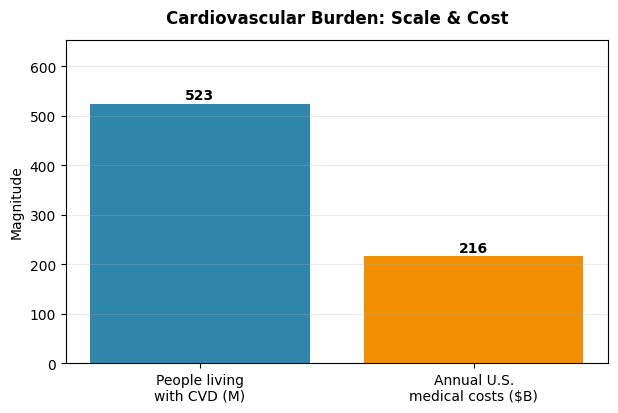

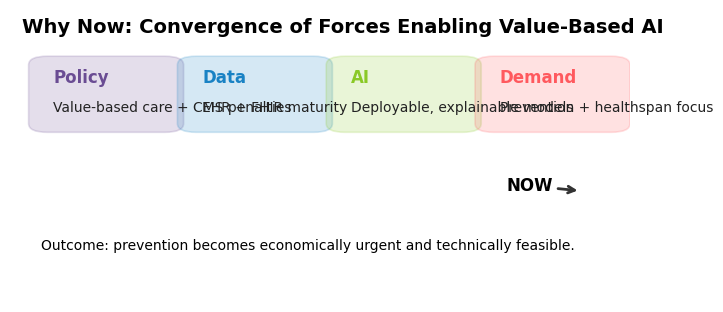

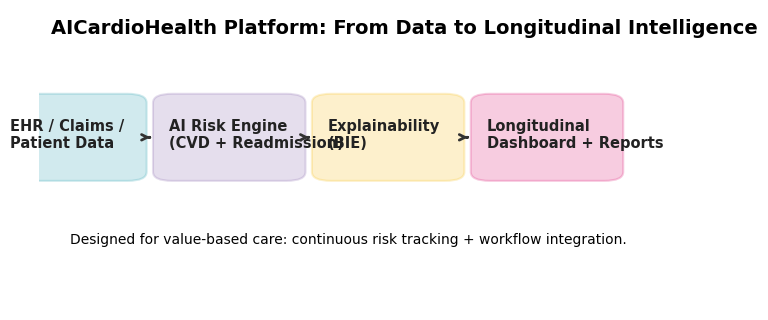

/tmp/ipython-input-2337110909.py:93: MatplotlibDeprecationWarning: There exists a non-polar current Axes. Therefore, the resulting plot from 'polar()' is non-polar. You likely should call 'polar()' before any other pyplot plotting commands. Support for this scenario is deprecated in 3.10 and will raise an error in 3.12
  plt.polar(angles, vals, color=color, lw=2, label=label)


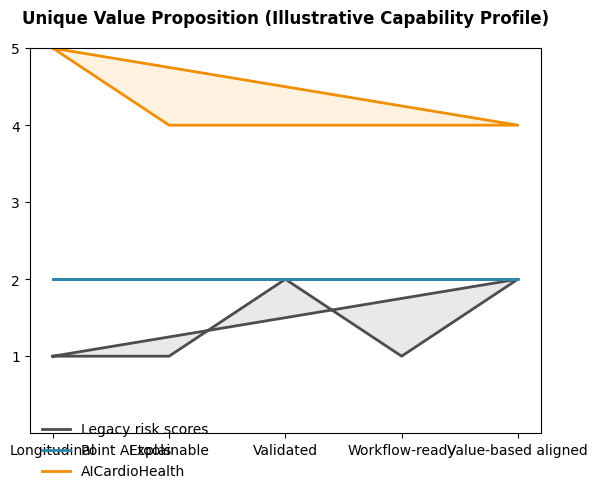

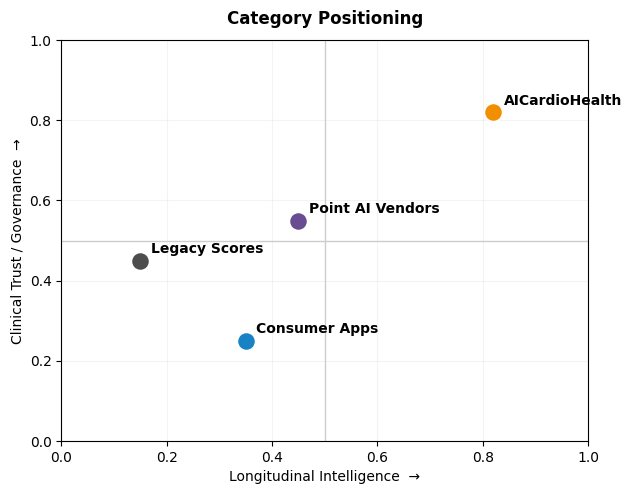

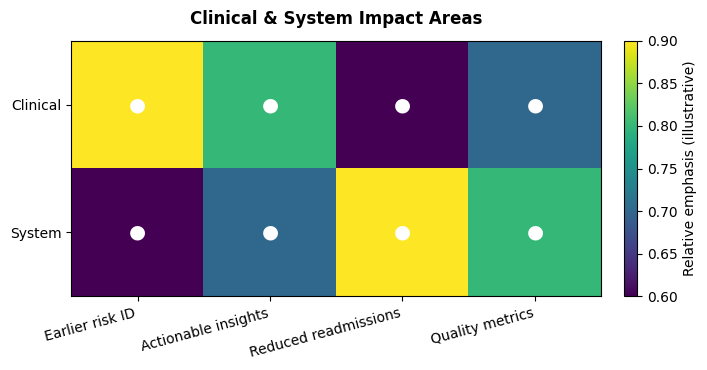

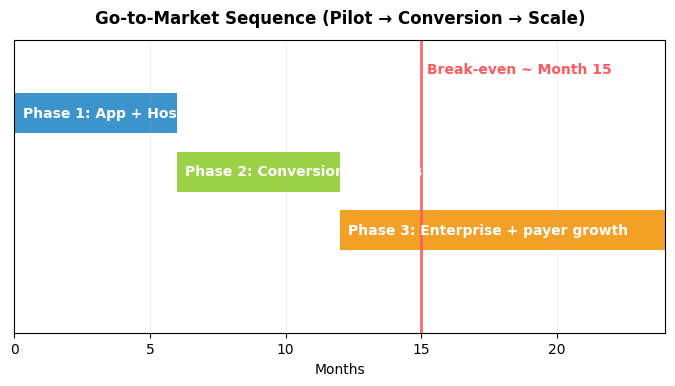

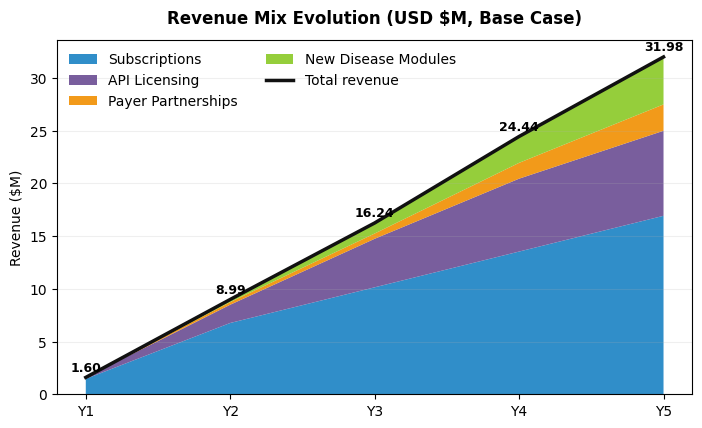

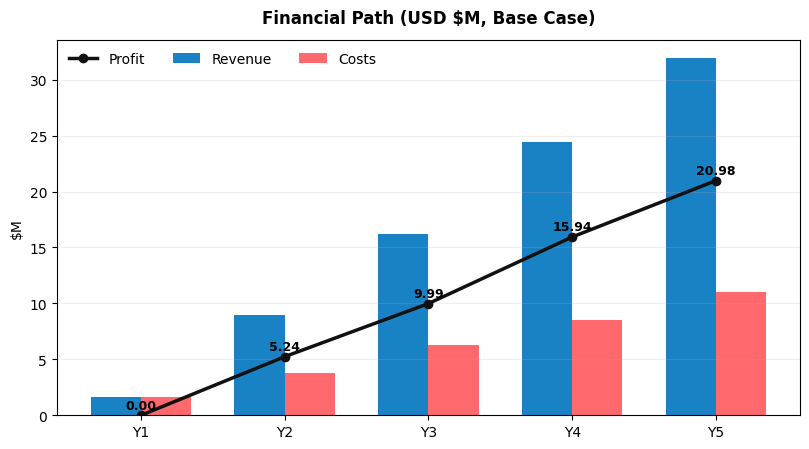

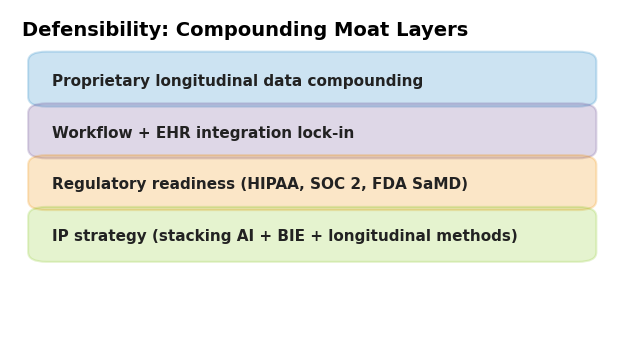

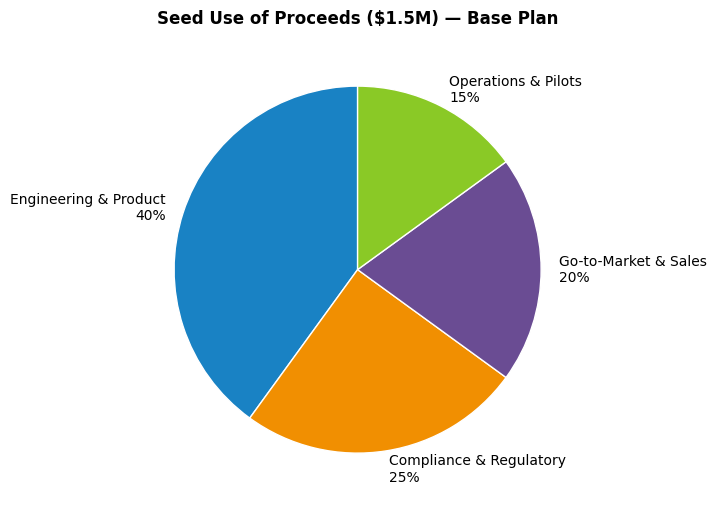

{'slide2_chart.png': '/mnt/data/slide2_chart.png',
 'slide3_chart.png': '/mnt/data/slide3_chart.png',
 'slide4_chart.png': '/mnt/data/slide4_chart.png',
 'slide5_chart.png': '/mnt/data/slide5_chart.png',
 'slide6_chart.png': '/mnt/data/slide6_chart.png',
 'slide7_chart.png': '/mnt/data/slide7_chart.png',
 'slide8_chart.png': '/mnt/data/slide8_chart.png',
 'slide9_chart.png': '/mnt/data/slide9_chart.png',
 'slide10_chart.png': '/mnt/data/slide10_chart.png',
 'slide11_chart.png': '/mnt/data/slide11_chart.png',
 'slide12_chart.png': '/mnt/data/slide12_chart.png'}

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch, ArrowStyle
from matplotlib.lines import Line2D
import os

out_dir = "/mnt/data"
paths = {}

def savefig(name):
    path = os.path.join(out_dir, name)
    plt.savefig(path, bbox_inches="tight", dpi=200)
    paths[name] = path

# ---------------- Slide 2: Problem scale (clean, colorful bar + callouts) ----------------
plt.figure(figsize=(7,4.2))
cats = ["People living\nwith CVD (M)", "Annual U.S.\nmedical costs ($B)"]
vals = [523, 216]
bars = plt.bar(cats, vals, color=["#2E86AB", "#F18F01"])
plt.title("Cardiovascular Burden: Scale & Cost", pad=12, fontweight="bold")
plt.ylabel("Magnitude")
for b, v in zip(bars, vals):
    plt.text(b.get_x()+b.get_width()/2, v*1.01, f"{v}", ha="center", va="bottom", fontweight="bold")
plt.ylim(0, max(vals)*1.25)
plt.grid(axis="y", alpha=0.25)
savefig("slide2_chart.png")
plt.show()

# ---------------- Slide 3: Why now (convergence timeline) ----------------
plt.figure(figsize=(8,3.8))
plt.axis("off")
title = "Why Now: Convergence of Forces Enabling Value-Based AI"
plt.text(0.02, 0.92, title, fontsize=14, fontweight="bold")

items = [
    ("Policy", "Value-based care + CMS penalties", "#6A4C93"),
    ("Data", "EHR + FHIR maturity", "#1982C4"),
    ("AI", "Deployable, explainable models", "#8AC926"),
    ("Demand", "Prevention + healthspan focus", "#FF595E"),
]
x0 = 0.05
y = 0.60
w = 0.21
h = 0.22
gap = 0.03
for i, (hdr, txt, col) in enumerate(items):
    x = x0 + i*(w+gap)
    box = FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.02,rounding_size=0.03",
                         linewidth=1.2, edgecolor=col, facecolor=col, alpha=0.18)
    plt.gca().add_patch(box)
    plt.text(x+0.02, y+h-0.07, hdr, fontsize=12, fontweight="bold", color=col)
    plt.text(x+0.02, y+0.05, txt, fontsize=10, color="#222222")
# arrow to "Now"
plt.annotate("NOW", xy=(0.92, 0.38), xytext=(0.80, 0.38),
             arrowprops=dict(arrowstyle="->", lw=2, color="#333333"),
             fontsize=12, fontweight="bold")
plt.text(0.05, 0.18, "Outcome: prevention becomes economically urgent and technically feasible.", fontsize=10)
savefig("slide3_chart.png")
plt.show()

# ---------------- Slide 4: Solution workflow diagram ----------------
plt.figure(figsize=(8.2,3.9))
plt.axis("off")
plt.text(0.02, 0.92, "AICardioHealth Platform: From Data to Longitudinal Intelligence",
         fontsize=14, fontweight="bold")
steps = [
    ("EHR / Claims /\nPatient Data", "#1B9AAA"),
    ("AI Risk Engine\n(CVD + Readmission)", "#7D5BA6"),
    ("Explainability\n(BIE)", "#F7B801"),
    ("Longitudinal\nDashboard + Reports", "#D90368"),
]
x = [0.05, 0.30, 0.55, 0.80]
for xi, (label, col) in zip(x, steps):
    box = FancyBboxPatch((xi-0.10, 0.45), 0.20, 0.25, boxstyle="round,pad=0.02,rounding_size=0.03",
                         linewidth=1.5, edgecolor=col, facecolor=col, alpha=0.20)
    plt.gca().add_patch(box)
    plt.text(xi-0.095, 0.54, label, fontsize=10.5, fontweight="bold", color="#222222")
for i in range(len(x)-1):
    plt.annotate("", xy=(x[i+1]-0.12, 0.575), xytext=(x[i]+0.12, 0.575),
                 arrowprops=dict(arrowstyle="->", lw=2, color="#333333"))
plt.text(0.05, 0.22, "Designed for value-based care: continuous risk tracking + workflow integration.", fontsize=10)
savefig("slide4_chart.png")
plt.show()

# ---------------- Slide 5: UVP radar (conceptual but clearer) ----------------
plt.figure(figsize=(6.6,5.0))
labels = ["Longitudinal", "Explainable", "Validated", "Workflow-ready", "Value-based aligned"]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

def radar(vals, color, label):
    vals = vals + vals[:1]
    plt.polar(angles, vals, color=color, lw=2, label=label)
    plt.fill(angles, vals, color=color, alpha=0.12)

# Scores are illustrative (not performance claims), to visually position the approach
legacy = [1, 1, 2, 1, 2]
point_ai = [2, 2, 2, 2, 2]
aich = [5, 4, 4, 4, 4]

plt.xticks(angles[:-1], labels)
plt.yticks([1,2,3,4,5], ["1","2","3","4","5"])
plt.ylim(0,5)
plt.title("Unique Value Proposition (Illustrative Capability Profile)", pad=18, fontweight="bold")
radar(legacy, "#4D4D4D", "Legacy risk scores")
radar(point_ai, "#2E86AB", "Point AI tools")
radar(aich, "#F18F01", "AICardioHealth")
plt.legend(loc="lower left", bbox_to_anchor=(0.0,-0.15), ncol=1, frameon=False)
savefig("slide5_chart.png")
plt.show()

# ---------------- Slide 6: Category positioning (2x2) ----------------
plt.figure(figsize=(6.8,5.2))
plt.axhline(0.5, color="#cccccc", lw=1)
plt.axvline(0.5, color="#cccccc", lw=1)
plt.xlim(0,1); plt.ylim(0,1)
plt.xlabel("Longitudinal Intelligence  →")
plt.ylabel("Clinical Trust / Governance  →")
plt.title("Category Positioning", pad=12, fontweight="bold")

points = [
    ("Legacy Scores", 0.15, 0.45, "#4D4D4D"),
    ("Consumer Apps", 0.35, 0.25, "#1982C4"),
    ("Point AI Vendors", 0.45, 0.55, "#6A4C93"),
    ("AICardioHealth", 0.82, 0.82, "#F18F01"),
]
for name, px, py, col in points:
    plt.scatter(px, py, s=180, color=col, edgecolor="white", linewidth=1.5, zorder=3)
    plt.text(px+0.02, py+0.02, name, fontsize=10, fontweight="bold")
plt.grid(alpha=0.15)
savefig("slide6_chart.png")
plt.show()

# ---------------- Slide 7: Impact heatmap (conceptual) ----------------
plt.figure(figsize=(7.2,3.8))
plt.title("Clinical & System Impact Areas", pad=12, fontweight="bold")
rows = ["Clinical", "System"]
cols = ["Earlier risk ID", "Actionable insights", "Reduced readmissions", "Quality metrics"]
data = np.array([[0.9, 0.8, 0.6, 0.7],
                 [0.6, 0.7, 0.9, 0.8]])
im = plt.imshow(data, aspect="auto", cmap="viridis")
plt.xticks(range(len(cols)), cols, rotation=15, ha="right")
plt.yticks(range(len(rows)), rows)
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        plt.text(j, i, "●", ha="center", va="center", color="white", fontsize=14)
plt.colorbar(im, fraction=0.046, pad=0.04, label="Relative emphasis (illustrative)")
plt.tight_layout()
savefig("slide7_chart.png")
plt.show()

# ---------------- Slide 8: GTM phases (timeline) ----------------
plt.figure(figsize=(8.4,3.8))
plt.title("Go-to-Market Sequence (Pilot → Conversion → Scale)", pad=12, fontweight="bold")
plt.yticks([])
plt.xlabel("Months")
plt.xlim(0, 24)
plt.ylim(0, 4)

segments = [
    ("Phase 1: App + Hospital pilots", 0, 6, 3.0, "#1982C4"),
    ("Phase 2: Conversion + expansion", 6, 12, 2.2, "#8AC926"),
    ("Phase 3: Enterprise + payer growth", 12, 24, 1.4, "#F18F01"),
]
for label, start, end, y, col in segments:
    plt.barh(y, end-start, left=start, height=0.55, color=col, alpha=0.85)
    plt.text(start+0.3, y, label, va="center", fontsize=10, fontweight="bold", color="white")

plt.axvline(15, lw=2, color="#FF595E", alpha=0.9)
plt.text(15.2, 3.55, "Break-even ~ Month 15", color="#FF595E", fontweight="bold", fontsize=10)

plt.grid(axis="x", alpha=0.2)
savefig("slide8_chart.png")
plt.show()

# ---------------- Slide 9: Revenue mix evolution (REAL data from v10.10) ----------------
years = np.array([1,2,3,4,5])
subs = np.array([1.46, 6.76, 10.14, 13.53, 16.92])
api  = np.array([0.14, 1.73, 4.60, 6.91, 8.06])
payer= np.array([0.00, 0.25, 0.50, 1.50, 2.50])
mods = np.array([0.00, 0.25, 1.00, 2.50, 4.50])
total = np.array([1.60, 8.99, 16.24, 24.44, 31.98])

plt.figure(figsize=(8.2,4.6))
plt.title("Revenue Mix Evolution (USD $M, Base Case)", pad=12, fontweight="bold")
plt.stackplot(years, subs, api, payer, mods, labels=["Subscriptions","API Licensing","Payer Partnerships","New Disease Modules"],
              colors=["#1982C4","#6A4C93","#F18F01","#8AC926"], alpha=0.9)
plt.plot(years, total, color="#111111", lw=2.5, label="Total revenue")
for x,y in zip(years, total):
    plt.text(x, y+0.6, f"{y:.2f}", ha="center", fontsize=9, fontweight="bold")
plt.xticks(years, [f"Y{i}" for i in years])
plt.ylabel("Revenue ($M)")
plt.grid(axis="y", alpha=0.2)
plt.legend(loc="upper left", frameon=False, ncol=2)
savefig("slide9_chart.png")
plt.show()

# ---------------- Slide 10: Revenue vs costs vs profit (REAL data from v10.10) ----------------
costs = np.array([1.60, 3.75, 6.25, 8.50, 11.00])
profit = np.array([0.00, 5.24, 9.99, 15.94, 20.98])

plt.figure(figsize=(8.2,4.6))
plt.title("Financial Path (USD $M, Base Case)", pad=12, fontweight="bold")
x = np.arange(len(years))
w = 0.35
plt.bar(x-w/2, total, width=w, label="Revenue", color="#1982C4")
plt.bar(x+w/2, costs, width=w, label="Costs", color="#FF595E", alpha=0.9)
plt.plot(x, profit, marker="o", lw=2.5, color="#111111", label="Profit")
for xi, p in zip(x, profit):
    plt.text(xi, p+0.6, f"{p:.2f}", ha="center", fontsize=9, fontweight="bold")
plt.xticks(x, [f"Y{i}" for i in years])
plt.ylabel("$M")
plt.grid(axis="y", alpha=0.2)
plt.legend(frameon=False, ncol=3, loc="upper left")
plt.tight_layout()
savefig("slide10_chart.png")
plt.show()

# ---------------- Slide 11: Defensibility moat layers (stacked blocks) ----------------
plt.figure(figsize=(7.8,4.2))
plt.axis("off")
plt.text(0.02, 0.92, "Defensibility: Compounding Moat Layers", fontsize=14, fontweight="bold")

layers = [
    ("Proprietary longitudinal data compounding", "#1982C4"),
    ("Workflow + EHR integration lock-in", "#6A4C93"),
    ("Regulatory readiness (HIPAA, SOC 2, FDA SaMD)", "#F18F01"),
    ("IP strategy (stacking AI + BIE + longitudinal methods)", "#8AC926"),
]
y = 0.72
for label, col in layers:
    rect = FancyBboxPatch((0.05, y), 0.90, 0.13, boxstyle="round,pad=0.02,rounding_size=0.03",
                          linewidth=1.5, edgecolor=col, facecolor=col, alpha=0.22)
    plt.gca().add_patch(rect)
    plt.text(0.07, y+0.045, label, fontsize=11, fontweight="bold", color="#222222")
    y -= 0.16
savefig("slide11_chart.png")
plt.show()

# ---------------- Slide 12: Use of proceeds (REAL data from v10.10) ----------------
labels = ["Engineering & Product\n40%", "Compliance & Regulatory\n25%", "Go-to-Market & Sales\n20%", "Operations & Pilots\n15%"]
sizes = [40,25,20,15]
colors = ["#1982C4","#F18F01","#6A4C93","#8AC926"]

plt.figure(figsize=(6.4,5.2))
plt.title("Seed Use of Proceeds ($1.5M) — Base Plan", pad=12, fontweight="bold")
wedges, texts = plt.pie(sizes, labels=labels, colors=colors, startangle=90, wedgeprops=dict(edgecolor="white"))
plt.tight_layout()
savefig("slide12_chart.png")
plt.show()

paths


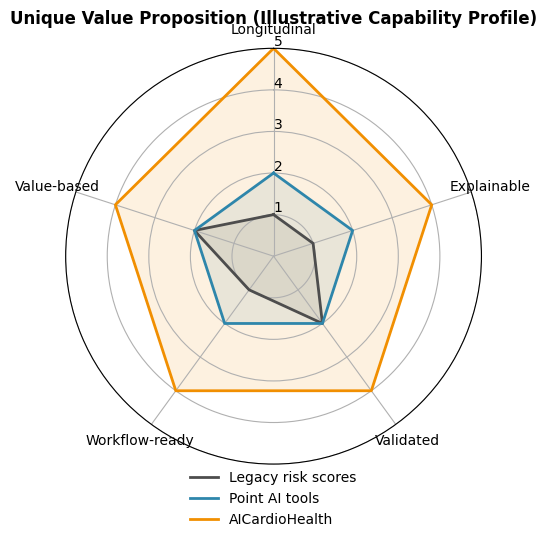

'/mnt/data/slide5_chart.png'

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os

out_dir="/mnt/data"

labels = ["Longitudinal", "Explainable", "Validated", "Workflow-ready", "Value-based"]
N = len(labels)
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]

legacy = [1, 1, 2, 1, 2]
point_ai = [2, 2, 2, 2, 2]
aich = [5, 4, 4, 4, 4]

def close(vals):
    return vals + vals[:1]

fig = plt.figure(figsize=(6.6,5.4))
ax = plt.subplot(111, polar=True)
ax.set_title("Unique Value Proposition (Illustrative Capability Profile)", pad=18, fontweight="bold")

ax.set_theta_offset(np.pi/2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_rlabel_position(0)
ax.set_yticks([1,2,3,4,5])
ax.set_yticklabels(["1","2","3","4","5"])
ax.set_ylim(0,5)

ax.plot(angles, close(legacy), color="#4D4D4D", lw=2, label="Legacy risk scores")
ax.fill(angles, close(legacy), color="#4D4D4D", alpha=0.10)

ax.plot(angles, close(point_ai), color="#2E86AB", lw=2, label="Point AI tools")
ax.fill(angles, close(point_ai), color="#2E86AB", alpha=0.10)

ax.plot(angles, close(aich), color="#F18F01", lw=2, label="AICardioHealth")
ax.fill(angles, close(aich), color="#F18F01", alpha=0.12)

ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.18), frameon=False, ncol=1)
path = os.path.join(out_dir, "slide5_chart.png")
plt.savefig(path, bbox_inches="tight", dpi=200)
plt.show()

path